# Paper figures drawn straight from result files: evaluation demo

This notebook demos the **evaluation script (`eval.py`)** of a deterministic, CPU-only paper figure set (figures F1–F7 plus an inferential-caveats table). The figures come from hashed result files of earlier artifacts, and no number is re-estimated.

`eval.py` scores the figure set on seven metric families:

| id | metric | what it checks |
|---|---|---|
| M1 | **value fidelity** | every plotted number re-read from its source file (exact / derived / image hash) |
| M2 | **record drift** | numbers quoted in the research record vs the source files (MATCH / DRIFT / NOT_FOUND) |
| M3 | **figure completeness** | each figure ships PDF + PNG + figure_spec + a well-formed caption + plotted_values + a passing check |
| M4 | **request coverage** | which requested activities have a figure |
| M5 | **production checks** | widths, fonts (≥ 6.5 pt, no Type 3), overlaps, colour-blind palette |
| M6 | **label integrity** | fold labels (SCREEN / CONFIRMATORY / …) shown on figures agree with the record |
| M7 | **spend** | USD spent (0, nothing re-estimated) |

**How this demo differs from the original run.** In the original, `main()` first runs one check script per figure (`checks/check_F*.py`, `production.py`, `lint_no_literals.py`, `drift.py`) as subprocesses. Those scripts re-open 57 hashed source files spread across the whole research run, so they cannot run here. The demo ships their **precomputed outputs** (`results/*.json`) in `mini_demo_data.json`, rebuilds a small workspace from them and runs the aggregation code of `eval.py` almost unchanged.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`. Two lines are commented out:
- `from independent import run_figure` was never used inside `eval.py`.
- `from src import style` only supplied the two figure widths, which are now read from the data (see below).

`pandas` and `matplotlib` are added for the final visualization.

In [2]:
from __future__ import annotations

import csv
import json
import re
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions (visualization + style stand-in) ---
from types import SimpleNamespace
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
Loads `mini_demo_data.json` from GitHub, with a local-file fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-5/evaluation-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f'{len(data["text_files"])} text files, {len(data["binary_file_names"])} binary figure files (names only)')

Snapshot of the inputs eval.py aggregates (gen_art_evaluation_9): per-figure check results, captions, labels, a diverse subset of plotted values and drift-report rows, plus the reference metrics_agg from the full run.
57 text files, 16 binary figure files (names only)


## Configuration

`eval.py` has no training loop and no sampling, so it has no compute knobs. The only scale knobs in this demo are how many rows from the two per-row datasets are loaded into the rebuilt workspace:

- `N_PV_ROWS_PER_FIGURE`: rows kept from each figure's `plotted_values.json`. `mini_demo_data.json` holds up to 10 diverse rows per figure; the full run has 957 rows in total.
- `N_DRIFT_ROWS`: rows kept from `results/drift_report.csv`. The data holds 30 rows (all 4 non-MATCH rows plus MATCH rows from distinct sources); the full run has 174.

These knobs change only the lists of per-row examples. The aggregate metrics (`metrics_agg`) come from the precomputed check summaries, so they match the full run at any setting.

In [5]:
N_PV_ROWS_PER_FIGURE = 10   # plotted_values rows per figure (max in data: 10; original: all, 957 in total)
N_DRIFT_ROWS = 30        # drift_report rows (max in data: 30; original: all 174)
DEMO_WS = Path("demo_ws")      # local stand-in for the artifact workspace

## Rebuilding the workspace

`eval.py` reads everything relative to `WS`, the directory holding the script. This cell writes the files from `data` into `demo_ws/`, applying the two row limits, so the original code below can read them from disk exactly as it did in the run.

- Binary figure files (PDF/PNG) are **not** shipped. `completeness()` only checks whether they exist (`d.glob("*.pdf")`), so empty placeholders with the original file names stand in for them.
- `style` becomes a small namespace holding the two Springer widths from `src/style.py` (174 mm double column, 84 mm single column).

The logger setup after that is the original.

In [6]:
for rel, txt in data["text_files"].items():
    p = DEMO_WS / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    if rel.endswith("values.json"):
        txt = json.dumps(json.loads(txt)[:N_PV_ROWS_PER_FIGURE], indent=1)
    elif rel == "results/drift_report.csv":
        lines = txt.splitlines(keepends=True)
        txt = "".join(lines[:1 + N_DRIFT_ROWS])  # header + first N rows
    p.write_text(txt)
for rel in data["binary_file_names"]:
    p = DEMO_WS / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.touch()  # existence-only placeholder for the real PDF/PNG
style = SimpleNamespace(**data["style"])

WS = DEMO_WS.resolve()  # original: Path(__file__).resolve().parent
sys.path.insert(0, str(WS))
sys.path.insert(0, str(WS / "checks"))
# from independent import run_figure  # noqa: E402   (unused in eval.py; needs the run's source registry)
# from src import style  # noqa: E402                (replaced by the namespace above)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

2

## Constants: figures, allowed fold labels, request coverage

- `ALLOWED` is the closed set of fold labels a figure row may show.
- `RECORD_MAP` folds the record's `SUPPLEMENTARY` / `POOLED` labels into one display label.
- `COVERAGE` is the hand-written map of the eight requested activities to figures (M4). Activity 8, related-work comparison, has no figure, which gives the 7/8 = 0.875 coverage.

In [7]:
FIGS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7"]
ALL_FIGS = FIGS[:6] + ["F6b", "F7"]
ALLOWED = {"SCREEN", "CONFIRMATORY", "REPLICATION", "SUPPLEMENTARY/POOLED", "MECHANISM", "DESCRIPTIVE",
           "POST-CONFIRMATION EXPLORATORY"}
RECORD_MAP = {"SUPPLEMENTARY": "SUPPLEMENTARY/POOLED", "POOLED": "SUPPLEMENTARY/POOLED"}
COVERAGE = [
    ("1 semantic grounding (frame, classifier/linker, corpus)", "F1 band 1", "shown", ""),
    ("2 two network views (co-word snapshots; concept-subfield bipartite)", "F1 band 2; F6b ego/alluvial",
     "shown", "network layouts are embedded from exp_8 (supplementary)"),
    ("3 RQ1 structural precursors of emergence", "F4", "shown", "R1_DEAD stated on the figure"),
    ("4 RQ2 diffusion across disciplinary boundaries (host entry, grafting)", "F2, F3", "shown", ""),
    ("5 diffusion typology", "F5; F1 band 4", "shown", ""),
    ("6 case studies (quantitatively selected)", "F6; F6b", "shown", ""),
    ("7 methodology in graphical form", "F1", "shown", ""),
    ("8 comparison to related work", "none", "not shown",
     "a literature comparison is prose/table work for the paper step; no figure here"),
]

## M3: figure completeness

`sentences()` counts caption sentences, leaving out the `F2.` prefix and abbreviations such as `e.g.`. A caption passes when it has 2–4 sentences, states a sample size (`n =`, or e.g. `1,544 events`), mentions CIs, and names a source path (`3_invention_loop/iter_k/gen_art/...`).

`completeness()` builds a boolean deliverable row per figure. The score is the fraction of true cells.

In [8]:
def sentences(text: str) -> int:
    body = re.sub(r"^F\d+b?\s*(\(\w+\))?\.\s*", "", text.strip())
    body = re.sub(r"\b(e\.g|i\.e|et al|vs|cf)\.", "x", body)
    return len([s for s in re.split(r"(?<=[.!?])\s+(?=[A-Z(])", body) if s.strip()])


def completeness() -> tuple[list[dict], float]:
    rows = []
    for f in FIGS:
        d = WS / "figures" / f
        cap = (d / "caption.md").read_text() if (d / "caption.md").exists() else ""
        chk = json.loads((WS / "results" / f"check_{f}.json").read_text()) if (
            WS / "results" / f"check_{f}.json").exists() else {"n_failed": 1}
        n_s = sentences(cap)
        cap_ok = (2 <= n_s <= 4 and bool(re.search(r"\bn\s*=|\bN\s*=|\b\d[\d,]*\s+(concepts|entries|draws|cases|"
                                                      r"strata|pairs|papers|events)", cap))
                  and bool(re.search(r"CI|confidence|no CIs|per row", cap))
                  and bool(re.search(r"3_invention_loop/iter_\d/gen_art/", cap)))
        rows.append({"figure": f, "pdf": any(d.glob("*.pdf")), "png": any(d.glob("*.png")),
                     "figure_spec": (d / "figure_spec.json").exists(), "caption": cap_ok,
                     "plotted_values": (d / "plotted_values.json").exists(),
                     "check_passes": chk["n_failed"] == 0 and (WS / "checks" / f"check_{f}.py").exists(),
                     "caption_sentences": n_s})
    cells = [v for r in rows for k, v in r.items() if k not in ("figure", "caption_sentences")]
    return rows, sum(cells) / len(cells)

## M6: label integrity

Each figure (and the caveats table) ships a `labels.json` giving the fold label **shown** on every row and, where one exists, the label the research **record** gives. A mismatch is either a shown label outside `ALLOWED` or a shown label that disagrees with the record (after `RECORD_MAP`).

In [9]:
def label_integrity() -> dict:
    labs = []
    for f in ALL_FIGS:
        p = WS / "figures" / f / "labels.json"
        if p.exists():
            labs += json.loads(p.read_text())
    labs += json.loads((WS / "tables" / "caveats_labels.json").read_text())
    bad_set = [l for l in labs if l["shown"] not in ALLOWED]
    mism = [l for l in labs if l.get("record_label") and RECORD_MAP.get(l["record_label"], l["record_label"])
            != l["shown"]]
    n_rec = sum(1 for l in labs if l.get("record_label"))
    return {"n_rows": len(labs), "n_with_record_label": n_rec, "not_in_allowed_set": bad_set,
            "record_mismatches": mism, "label_mismatches": len(bad_set) + len(mism)}

## `main()`: aggregate all metrics and write `eval_out.json`

This is the original `main()` with one change. The two `subprocess.run(...)` lines that launched the check scripts are commented out. The scripts need the run's 57 hashed source files, so their stored JSON outputs are read directly instead. The rest of the function is unchanged:

1. **M1 fidelity**: sums `n_values / n_exact / n_derived / n_images / n_failed` over the per-figure check JSONs; `value_fidelity = (n_values - n_failed) / n_values`.
2. **M2 drift**: status counts from `drift_summary.json`.
3. **M3, M4, M5, M6**: completeness, coverage, production checks and label integrity.
4. **Per-row datasets**: one example per plotted value (with source path, artifact id, sha256 and fold label), per drift-report quote, per figure deliverable, per coverage activity and per production check. These go into `eval_out.json` in the `exp_eval_sol_out` layout.

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    logger.info("running per-figure checks")
    checks = {}
    for f in ALL_FIGS + ["caveats"]:
        # rc = subprocess.run([sys.executable, str(WS / "checks" / f"check_{f}.py")], capture_output=True, text=True)
        checks[f] = json.loads((WS / "results" / f"check_{f}.json").read_text())
        logger.info(f"check_{f}: (precomputed) n_values {checks[f]['n_values']} failed {checks[f]['n_failed']}")
    for script in ("production.py", "lint_no_literals.py", "drift.py"):
        # rc = subprocess.run([sys.executable, str(WS / "checks" / script)], capture_output=True, text=True)
        logger.info(f"{script}: (precomputed output used)")
    prod = json.loads((WS / "results" / "production_checks.json").read_text())
    lint = json.loads((WS / "results" / "lint_no_literals.json").read_text())
    drift = json.loads((WS / "results" / "drift_summary.json").read_text())
    selftest = json.loads((WS / "results" / "check_selftest.json").read_text())
    comp_rows, comp = completeness()
    labels = label_integrity()
    n_val = sum(c["n_values"] for c in checks.values())
    n_fail = sum(c["n_failed"] for c in checks.values())
    fidelity = {"n_values": n_val, "n_exact": sum(c["n_exact"] for c in checks.values()),
                "n_derived": sum(c["n_derived"] for c in checks.values()),
                "n_images": sum(c["n_images"] for c in checks.values()), "n_failed": n_fail,
                "n_source_missing_not_plotted": sum(c["n_source_missing"] for c in checks.values()),
                "value_fidelity": (n_val - n_fail) / n_val if n_val else 0.0, "per_figure": checks}
    (WS / "results" / "fidelity_summary.json").write_text(json.dumps(fidelity, indent=1, default=str))
    with (WS / "results" / "figure_completeness.csv").open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(comp_rows[0]))
        w.writeheader()
        w.writerows(comp_rows)
    with (WS / "results" / "request_coverage.csv").open("w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["activity", "figure_or_panel", "status", "reason"])
        w.writerows(COVERAGE)
    (WS / "results" / "label_integrity.json").write_text(json.dumps(labels, indent=1, default=str))
    metrics = {
        "value_fidelity": fidelity["value_fidelity"], "n_plotted_values": n_val, "n_exact": fidelity["n_exact"],
        "n_derived": fidelity["n_derived"], "n_images_hash_checked": fidelity["n_images"], "n_failed": n_fail,
        "n_source_missing_not_plotted": fidelity["n_source_missing_not_plotted"],
        "n_record_expectations": drift["n"], "n_match": drift["counts"]["MATCH"],
        "n_rounding_diff": drift["counts"]["ROUNDING_DIFF"], "n_drift": drift["counts"]["DRIFT"],
        "n_not_found": drift["counts"]["NOT_FOUND"], "figure_completeness": comp,
        "request_coverage_shown_fraction": sum(c[2] == "shown" for c in COVERAGE) / len(COVERAGE),
        "min_font_pt": min(p["min_font_pt"] for p in prod), "n_text_overlaps": sum(p["n_text_overlaps"] for p in prod),
        "production_pass_fraction": sum(p["pass"] for p in prod) / len(prod),
        "label_mismatches": labels["label_mismatches"], "lint_literal_hits": lint["n_hits"],
        "mutation_selftest_pass": float(selftest["selftest_pass"]), "openrouter_usd": 0.0,
    }
    ex_pv = []
    for f in ALL_FIGS + ["caveats"]:
        p = (WS / "tables" / "caveats_values.json") if f == "caveats" else (WS / "figures" / f / "plotted_values.json")
        failed = {(x["panel"], x["row"], x["field"]) for x in checks[f]["failures"]}
        for r in json.loads(p.read_text()):
            if r.get("status") != "OK":
                continue
            ex_pv.append({"input": f"{r['figure']} | panel {r['panel']} | row {r['row']} | {r['field']}",
                          "output": str(r["value"]), "metadata_key": r["key"],
                          "metadata_source_path": r.get("path", ""), "metadata_artifact_id": r.get("artifact_id", ""),
                          "metadata_sha256": r.get("sha256", ""), "metadata_fold_label": r.get("fold_label", ""),
                          "metadata_ci_type": r.get("ci_type", ""), "metadata_source_kind": r.get("source_kind", ""),
                          "metadata_display_string": r.get("display_string") or "",
                          "predict_figure": str(r["value"]),
                          "eval_value_match": 0.0 if (r["panel"], r["row"], r["field"]) in failed else 1.0})
    ex_drift = []
    for r in csv.DictReader((WS / "results" / "drift_report.csv").open()):
        ex_drift.append({"input": f"record quote {r['key']}: {r['quoted']}", "output": r["source_value"] or "NOT_FOUND",
                         "metadata_status": r["status"], "metadata_source": r["source"],
                         "metadata_note": r["note"], "predict_record": r["quoted"],
                         "eval_match": 1.0 if r["status"] == "MATCH" else 0.0})
    ex_comp = [{"input": f"figure {r['figure']} deliverables", "output": json.dumps(r),
                "predict_complete": str(all(v for k, v in r.items() if k not in ("figure", "caption_sentences"))),
                "eval_complete": float(all(v for k, v in r.items() if k not in ("figure", "caption_sentences")))}
               for r in comp_rows]
    ex_cov = [{"input": a, "output": f"{fp} ({st})", "metadata_reason": rsn, "predict_status": st,
               "eval_shown": 1.0 if st == "shown" else 0.0} for a, fp, st, rsn in COVERAGE]
    ex_prod = [{"input": f"production {p['figure']}", "output": "PASS" if p["pass"] else "FAIL",
                "predict_check": "PASS" if p["pass"] else "FAIL",
                "metadata_detail": json.dumps({k: v for k, v in p.items() if k != "colourblind"}),
                "eval_pass": float(p["pass"]), "eval_min_font_pt": float(p["min_font_pt"])} for p in prod]
    out = {"metadata": {"evaluation_name": "paper figure set drawn straight from result files",
                        "artifact_plan": "gen_plan_evaluation_4_idx5",
                        "description": "Fidelity, drift, completeness, coverage, production and label checks for "
                                       "figures F1-F7 and the inferential caveats table; nothing re-estimated.",
                        "figure_widths_mm": [style.W_DOUBLE_MM, style.W_SINGLE_MM]},
           "metrics_agg": metrics,
           "datasets": [{"dataset": "plotted_values", "examples": ex_pv}, {"dataset": "drift", "examples": ex_drift},
                        {"dataset": "figure_completeness", "examples": ex_comp},
                        {"dataset": "request_coverage", "examples": ex_cov},
                        {"dataset": "production_checks", "examples": ex_prod}]}
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1, default=str))
    logger.info(json.dumps(metrics))

## Run the evaluation

In [11]:
main()
eval_out = json.loads((WS / "eval_out.json").read_text())
print({d["dataset"]: len(d["examples"]) for d in eval_out["datasets"]})

21:14:58|INFO   |running per-figure checks


21:14:58|INFO   |check_F1: (precomputed) n_values 39 failed 0


21:14:58|INFO   |check_F2: (precomputed) n_values 124 failed 0


21:14:58|INFO   |check_F3: (precomputed) n_values 163 failed 0


21:14:58|INFO   |check_F4: (precomputed) n_values 102 failed 0


...

21:14:58|INFO   |production.py: (precomputed output used)


21:14:58|INFO   |lint_no_literals.py: (precomputed output used)


21:14:58|INFO   |drift.py: (precomputed output used)


21:14:59|INFO   |{"value_fidelity": 1.0, "n_plotted_values": 957, "n_exact": 939, "n_derived": 10, "n_images_hash_checked": 8, "n_failed": 0, "n_source_missing_not_plotted": 9, "n_record_expectations": 174, "n_match": 170, "n_rounding_diff": 0, "n_drift": 3, "n_not_found": 1, "figure_completeness": 1.0, "request_coverage_shown_fraction": 0.875, "min_font_pt": 6.5, "n_text_overlaps": 0, "production_pass_fraction": 1.0, "label_mismatches": 0, "lint_literal_hits": 0, "mutation_selftest_pass": 1.0, "openrouter_usd": 0.0}


{'plotted_values': 66, 'drift': 30, 'figure_completeness': 7, 'request_coverage': 8, 'production_checks': 8}


## Results

1. The recomputed `metrics_agg` next to the reference values from the full original run. They should agree exactly, since both come from the same check summaries.
2. The per-row example tables (drift quotes, figure deliverables).
3. Four summary plots: plotted values per figure by verification kind, record-drift status counts, the deliverable completeness grid, and the production-check minimum font size per figure.

In [12]:
ref = data["reference_metrics_agg"]
m = eval_out["metrics_agg"]
cmp_df = pd.DataFrame({"demo": m, "full run (reference)": ref})
cmp_df["equal"] = [m[k] == ref.get(k) for k in cmp_df.index]
print(cmp_df.to_string())
print("\nall metrics equal to reference:", bool(cmp_df["equal"].all()))
print("examples per dataset (demo vs full run):",
      {d["dataset"]: (len(d["examples"]), data["reference_n_examples"][d["dataset"]]) for d in eval_out["datasets"]})

ds = {d["dataset"]: pd.DataFrame(d["examples"]) for d in eval_out["datasets"]}
pd.set_option("display.max_colwidth", 70)
print("\nRecord drift examples:")
print(ds["drift"][["input", "output", "metadata_status"]].to_string(index=False))
print("\nPlotted-value examples:")
print(ds["plotted_values"][["input", "output", "metadata_fold_label", "eval_value_match"]].to_string(index=False))

                                    demo  full run (reference)  equal
value_fidelity                     1.000                 1.000   True
n_plotted_values                 957.000               957.000   True
n_exact                          939.000               939.000   True
n_derived                         10.000                10.000   True
n_images_hash_checked              8.000                 8.000   True
n_failed                           0.000                 0.000   True
n_source_missing_not_plotted       9.000                 9.000   True
n_record_expectations            174.000               174.000   True
n_match                          170.000               170.000   True
n_rounding_diff                    0.000                 0.000   True
n_drift                            3.000                 3.000   True
n_not_found                        1.000                 1.000   True
figure_completeness                1.000                 1.000   True
request_coverage_sho

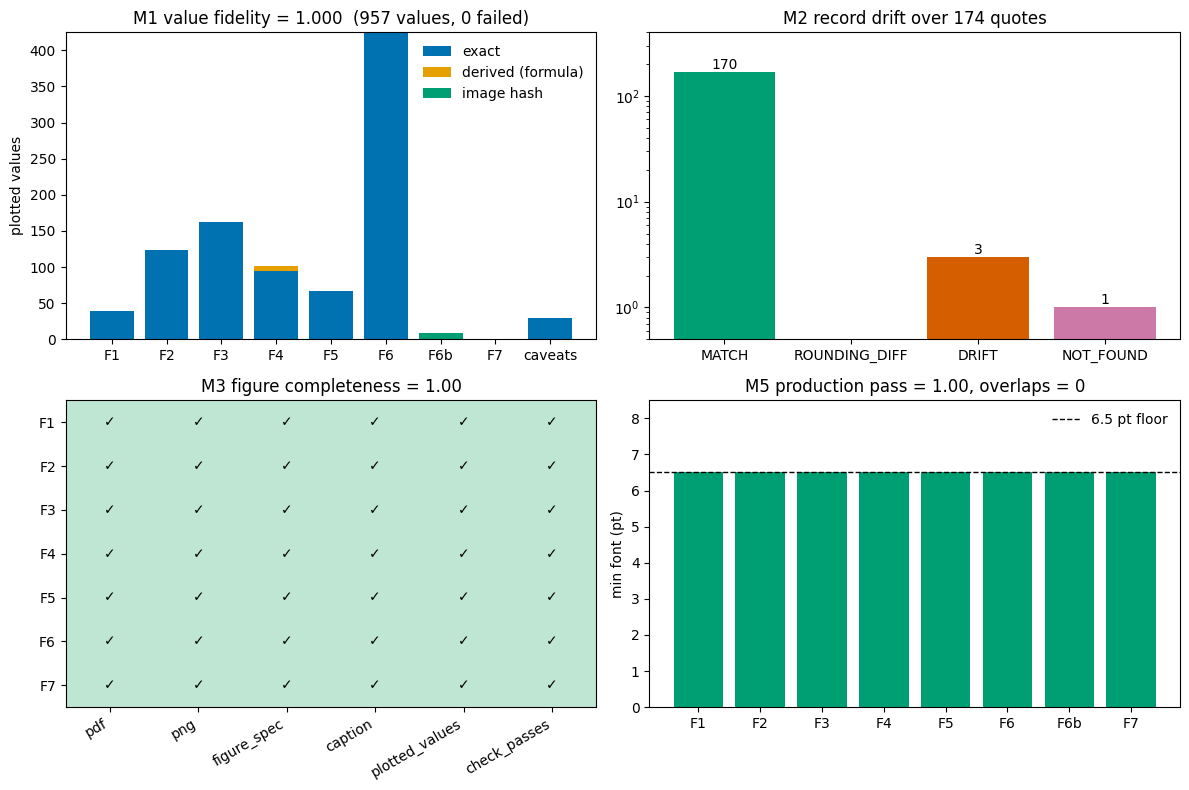

In [13]:
fid = json.loads((WS / "results" / "fidelity_summary.json").read_text())["per_figure"]
drift_counts = json.loads((WS / "results" / "drift_summary.json").read_text())["counts"]
comp_df = pd.read_csv(WS / "results" / "figure_completeness.csv").set_index("figure")
prod = json.loads((WS / "results" / "production_checks.json").read_text())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# (a) plotted values per figure, split by verification kind
names = list(fid)
exact = [fid[n]["n_exact"] for n in names]; derived = [fid[n]["n_derived"] for n in names]
images = [fid[n]["n_images"] for n in names]; failed = [fid[n]["n_failed"] for n in names]
ax = axes[0, 0]
ax.bar(names, exact, label="exact", color="#0072B2")
ax.bar(names, derived, bottom=exact, label="derived (formula)", color="#E69F00")
ax.bar(names, images, bottom=[a + b for a, b in zip(exact, derived)], label="image hash", color="#009E73")
ax.set_title(f"M1 value fidelity = {m['value_fidelity']:.3f}  ({m['n_plotted_values']} values, {sum(failed)} failed)")
ax.set_ylabel("plotted values"); ax.legend(frameon=False)
# (b) record drift status counts
ax = axes[0, 1]
ks = list(drift_counts); vs = [drift_counts[k] for k in ks]
bars = ax.bar(ks, vs, color=["#009E73", "#56B4E9", "#D55E00", "#CC79A7"])
ax.bar_label(bars); ax.set_yscale("log"); ax.set_ylim(0.5, 400)
ax.set_title(f"M2 record drift over {m['n_record_expectations']} quotes")
# (c) completeness grid
ax = axes[1, 0]
grid = comp_df.drop(columns="caption_sentences").astype(float)
from matplotlib.colors import ListedColormap
ax.imshow(grid.values, cmap=ListedColormap(["#F6C6B0", "#BFE6D2"]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=30, ha="right")
ax.set_yticks(range(grid.shape[0]), grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, "✓" if grid.values[i, j] else "✗", ha="center", va="center")
ax.set_title(f"M3 figure completeness = {m['figure_completeness']:.2f}")
# (d) production: min font size per figure vs the 6.5 pt floor
ax = axes[1, 1]
ax.bar([p["figure"] for p in prod], [p["min_font_pt"] for p in prod],
       color=["#009E73" if p["pass"] else "#D55E00" for p in prod])
ax.axhline(6.5, color="k", ls="--", lw=1, label="6.5 pt floor")
ax.set_ylabel("min font (pt)"); ax.set_ylim(0, 8.5); ax.legend(frameon=False, loc="upper right")
ax.set_title(f"M5 production pass = {m['production_pass_fraction']:.2f}, overlaps = {m['n_text_overlaps']}")
plt.tight_layout(); plt.show()